In [1]:
from crack_seg.config import *
from PIL import Image
import matplotlib.pyplot as plt
from crack_seg.data_handlers.dataset import CrackDataset
from crack_seg.data_handlers.transforms import (
    train_img_transform,
    train_mask_transform,
    val_img_transform,
    val_mask_transform,
)
from crack_seg.predict import predict
import importlib
import numpy as np

In [2]:
list(DATA_ROOT.iterdir())

[WindowsPath('CConCrack/info.txt'),
 WindowsPath('CConCrack/Test'),
 WindowsPath('CConCrack/Train')]

In [3]:
# print(type(TRAIN_IMG_DIR), TRAIN_IMG_DIR)

# img_path = list(TRAIN_IMG_DIR.iterdir())[0]
# print(img_path)

# img = Image.open(img_path)
# plt.imshow(img)
# plt.axis("off")  # Hide axes for better visualization
# plt.show()    

In [4]:
# 1. Dynamically import the model module and instantiate the model
model_module = importlib.import_module(f"crack_seg.models.{MODEL_NAME}")
model = model_module.get_model().to(DEVICE)
# 2. Load the state dictionary
checkpoint_path = Path(CHECKPOINT_DIR) / f"{MODEL_NAME}_best.pth"
state_dict = torch.load(checkpoint_path, map_location=DEVICE)
model.load_state_dict(state_dict)
# 3. Set model to evaluation mode (important for inference)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

c:\Users\abinashm\AppData\Local\anaconda3\envs\computerVision\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


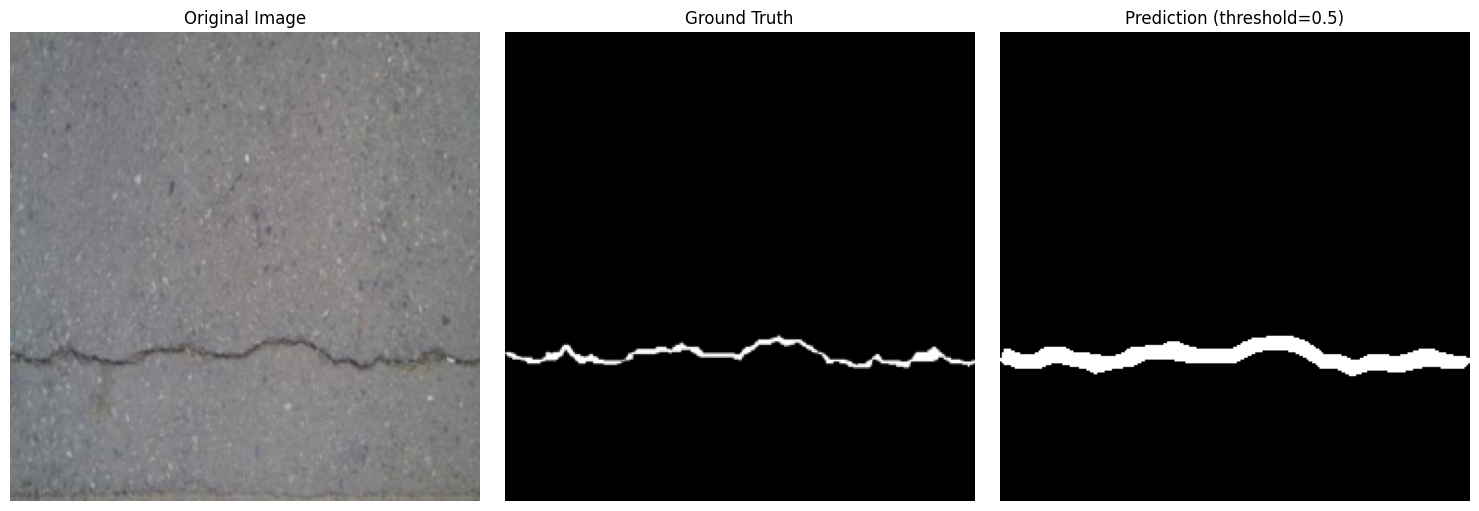

In [5]:
# Assuming you've loaded model and have it on device
from crack_seg.data_handlers.transforms import val_img_transform
from crack_seg.utils.visualization import display_prediction

display_prediction(
    image_path="CConCrack/Test/images/CFD_005.jpg",
    model=model,
    device=device,
    transform=val_img_transform,
    mask_dir="CConCrack/Test/masks",  # optional; can be omitted if folder structure is consistent
    threshold=0.5
)

In [6]:
device

device(type='cuda')